# Customer Behavior Analysis — Alfido Tech
**Intern Spark | Data Analyst Internship Project**

**Dataset:** [Customer Behavior Analysis (Kaggle)](https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis)
**Prepared by:** Data Analyst Intern
**Objective:** Analyze customer transactions and behavior to identify segments, purchase patterns, and churn risks for Alfido Tech, and provide actionable recommendations to improve customer engagement.

---

### Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning](#2)
3. [Feature Engineering (RFM)](#3)
4. [Customer Segmentation](#4)
5. [Segment Cross-Check with Clustering](#5)
6. [Purchase Patterns & Visualizations](#6)
7. [Retention & Churn Analysis](#7)
8. [Key Findings](#8)
9. [Actionable Recommendations for Alfido Tech](#9)


## 1. Setup & Data Loading <a id='1'></a>

The dataset contains two files with identical schema:
- `ecommerce_customer_data_large.csv` — 250,000 transaction rows (main analysis file)
- `ecommerce_customer_data_custom_ratios.csv` — a resampled variant with custom class ratios

We use the **large** file as the primary dataset since it represents the full, unmodified transaction history.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

COLOR_PRIMARY = "#2C6E8F"
COLOR_ACCENT  = "#E8A23D"
PALETTE = ["#2C6E8F", "#E8A23D", "#5B8C5A", "#C15A5A", "#7C6BA6", "#4FA8A0"]

%matplotlib inline

In [2]:
df = pd.read_csv("archive_extracted/ecommerce_customer_data_large.csv")
print("Shape:", df.shape)
df.head()

Shape: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


## 2. Data Cleaning <a id='2'></a>

Checks performed:
- Missing values
- Duplicate rows
- Redundant columns
- Data type conversions (dates)
- Basic range/outlier sanity checks


In [4]:
# Missing values
df.isna().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Only the **`Returns`** column has missing values (~19% of rows). Given that the column is otherwise binary (0 = not returned, 1 = returned), missing values most likely represent unrecorded return status rather than a special category. We treat them as **not returned (0)** — a conservative choice that avoids inflating the return rate.

In [5]:
df['Returns'] = df['Returns'].fillna(0).astype(int)

In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


`Age` and `Customer Age` are identical columns — we drop the redundant one.

In [7]:
assert (df['Age'] == df['Customer Age']).all()
df = df.drop(columns=['Age'])

In [8]:
# Parse purchase date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
print("Date range:", df['Purchase Date'].min(), "to", df['Purchase Date'].max())

Date range: 2020-01-01 00:07:26 to 2023-09-13 18:42:49


In [9]:
# Range / sanity checks on key numeric fields
df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']].describe()

,Product Price,Quantity,Total Purchase Amount,Customer Age
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,254.742724,3.004936,2725.385196,43.798276
std,141.738104,1.414737,1442.576095,15.364915
min,10.000000,1.000000,100.000000,18.000000
25%,132.000000,2.000000,1476.000000,30.000000
50%,255.000000,3.000000,2725.000000,44.000000
75%,377.000000,4.000000,3975.000000,57.000000
max,500.000000,5.000000,5350.000000,70.000000


No negative values, impossible ages, or extreme outliers are present. The dataset is **transaction-level**: each row is one purchase line item, and a customer can appear multiple times.

In [10]:
print("Unique customers:", df['Customer ID'].nunique())
print("Total transactions:", len(df))
print("Avg transactions per customer:", round(len(df)/df['Customer ID'].nunique(), 2))

Unique customers: 49661
Total transactions: 250000
Avg transactions per customer: 5.03


## 3. Feature Engineering — Building a Customer-Level RFM Table <a id='3'></a>

To analyze **behavior** rather than individual transactions, we roll the data up to one row per customer and compute classic **RFM** metrics:

- **Recency** — days since the customer's last purchase (relative to the day after the last date in the dataset)
- **Frequency** — total number of purchases made
- **Monetary** — total amount spent

Plus supporting features: average order value, return rate, tenure, favorite category, preferred payment method, age, gender, and the churn flag.


In [11]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

customer = df.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum'),
    AvgOrderValue=('Total Purchase Amount', 'mean'),
    FirstPurchase=('Purchase Date', 'min'),
    LastPurchase=('Purchase Date', 'max'),
    ReturnRate=('Returns', 'mean'),
    Age=('Customer Age', 'first'),
    Gender=('Gender', 'first'),
    Churn=('Churn', 'first'),
    FavoriteCategory=('Product Category', lambda x: x.mode()[0]),
    PreferredPayment=('Payment Method', lambda x: x.mode()[0]),
).reset_index()

customer['TenureDays'] = (customer['LastPurchase'] - customer['FirstPurchase']).dt.days

print(customer.shape)
customer.head()

(49661, 14)


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,FirstPurchase,LastPurchase,ReturnRate,Age,Gender,Churn,FavoriteCategory,PreferredPayment,TenureDays
0,1,289,3,6290,2096.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,0.000000,67,Female,0,Books,Credit Card,999
1,2,73,6,16481,2746.833333,2020-07-31 16:27:41,2023-07-03 17:26:19,0.666667,42,Female,0,Electronics,PayPal,1067
2,3,223,4,9423,2355.750000,2020-01-19 00:03:00,2023-02-03 03:58:07,0.000000,31,Male,0,Electronics,Credit Card,1111
3,4,442,5,7826,1565.200000,2020-10-12 22:03:10,2022-06-29 03:41:09,0.600000,37,Male,0,Books,Cash,624
4,5,425,5,9769,1953.800000,2020-04-08 21:57:19,2022-07-16 04:08:09,0.600000,24,Female,0,Home,Credit Card,828


## 4. Customer Segmentation <a id='4'></a>

Each customer is scored 1–4 (quartiles) on Recency, Frequency and Monetary value, then mapped to a business-friendly segment:

| Segment | Meaning |
|---|---|
| **Champions** | Bought recently, often, and spend the most |
| **Loyal Customers** | Buy regularly and fairly recently |
| **New / Promising** | Recent buyers who haven't purchased often yet |
| **At Risk** | Used to buy often/a lot, but haven't purchased recently |
| **Needs Attention** | Average recency/frequency — could go either way |
| **Hibernating / Lost** | Long time since last purchase, low frequency and spend |


In [12]:
customer['R_Score'] = pd.qcut(customer['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
customer['F_Score'] = pd.qcut(customer['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
customer['M_Score'] = pd.qcut(customer['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
customer['RFM_Score'] = customer['R_Score'] + customer['F_Score'] + customer['M_Score']

def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if r >= 3 and f >= 3:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New / Promising'
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating / Lost'
    return 'Needs Attention'

customer['Segment'] = customer.apply(rfm_segment, axis=1)
customer['Segment'].value_counts()

Segment
Hibernating / Lost    13245
Loyal Customers       11939
At Risk                9371
Needs Attention        7267
New / Promising        4319
Champions              3520
Name: count, dtype: int64

In [13]:
seg_summary = customer.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_ReturnRate=('ReturnRate', 'mean'),
    ChurnRate=('Churn', 'mean'),
).round(2).sort_values('Avg_Monetary', ascending=False)
seg_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_ReturnRate,ChurnRate
Segment,,,,,,
Champions,3520,36.40,8.43,24147.47,0.40,0.21
At Risk,9371,346.95,6.44,17572.06,0.41,0.20
Loyal Customers,11939,92.74,6.52,17369.03,0.41,0.20
Needs Attention,7267,215.52,3.82,11431.20,0.40,0.19
New / Promising,4319,38.10,3.63,9860.60,0.41,0.20
Hibernating / Lost,13245,514.19,2.92,7448.25,0.41,0.20


**Segment profile narrative:**

- **Champions** (~7% of customers) are the most recent, most frequent, highest-spending group — the core of Alfido Tech's revenue base per customer.
- **Loyal Customers** (~24%) buy regularly and are only slightly less recent than Champions — the largest high-value group by headcount.
- **At Risk** (~19%) used to spend heavily/often but haven't purchased in a long time — the highest-priority group for win-back campaigns.
- **Hibernating / Lost** (~27%, the largest segment) have low recency, frequency and spend — likely one-time or long-dormant buyers.
- **New / Promising** (~9%) are recent but low-frequency — early-stage customers worth nurturing.
- **Needs Attention** (~15%) sit in the middle on all metrics.

## 5. Segment Cross-Check with K-Means Clustering <a id='5'></a>

As a robustness check on the rule-based RFM segments, we also run **K-Means clustering** directly on standardized Recency/Frequency/Monetary values.


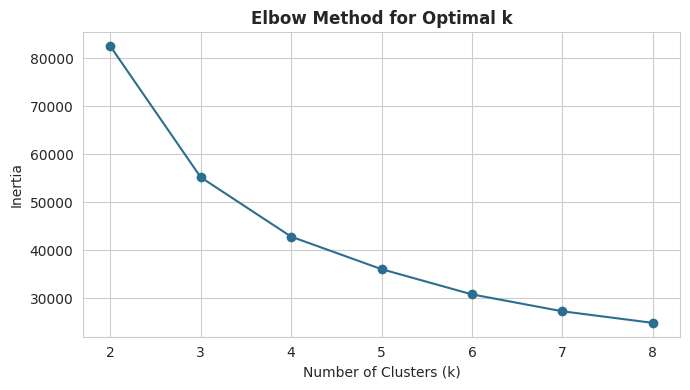

In [14]:
rfm_features = customer[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o', color=COLOR_PRIMARY)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

cluster_summary = customer.groupby('Cluster').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    ChurnRate=('Churn', 'mean'),
).round(2)
cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,ChurnRate
Cluster,,,,,
0,7588,723.22,2.92,7801.51,0.2
1,8236,140.49,8.46,24490.67,0.2
2,15199,198.00,3.38,8406.97,0.2
3,18638,181.00,5.73,15702.64,0.2


In [16]:
pd.crosstab(customer['Segment'], customer['Cluster'])

Cluster,0,1,2,3
Segment,,,,
At Risk,661,2296,422,5992
Champions,0,3116,0,404
Hibernating / Lost,6387,0,6606,252
Loyal Customers,0,2824,508,8607
Needs Attention,540,0,4366,2361
New / Promising,0,0,3297,1022


The clusters broadly agree with the RFM segments — high-recency/high-frequency/high-monetary customers cluster together (roughly matching Champions/Loyal), while low-value/dormant customers form their own cluster (matching Hibernating/Lost). This cross-validation gives us confidence that the RFM segmentation reflects real structure in the data, not an artifact of the scoring rules.

## 6. Purchase Patterns & Visualizations <a id='6'></a>

### 6.1 Segment Sizes

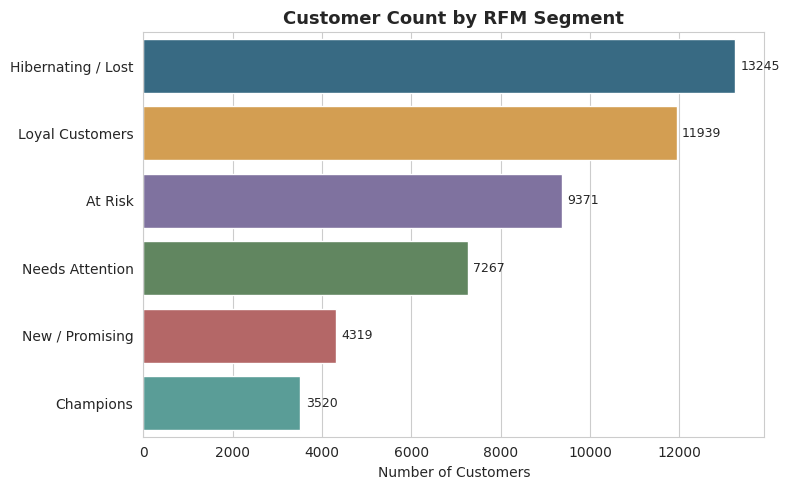

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
order = customer['Segment'].value_counts().index
sns.countplot(data=customer, y='Segment', order=order, hue='Segment', palette=PALETTE, legend=False, ax=ax)
ax.set_title('Customer Count by RFM Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=9, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

### 6.2 Average Lifetime Spend by Segment

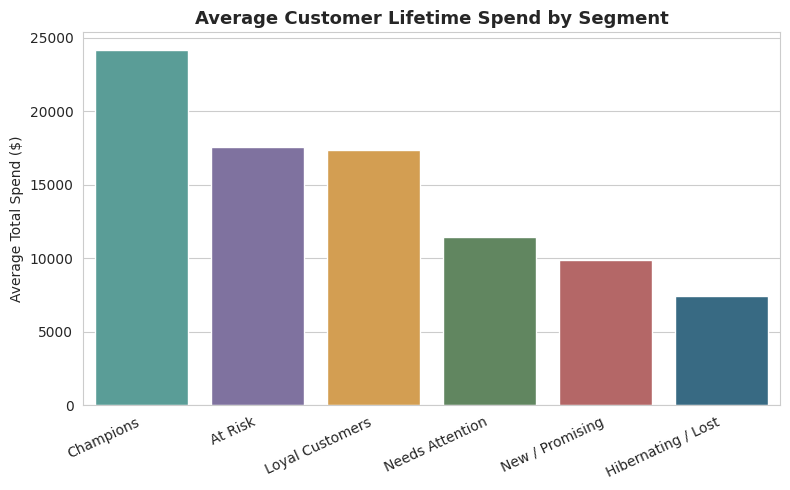

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=customer, x='Segment', y='Monetary', estimator=np.mean,
            order=seg_summary.index, hue='Segment', palette=PALETTE, legend=False, ax=ax, errorbar=None)
ax.set_title('Average Customer Lifetime Spend by Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Total Spend ($)')
ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 6.3 Monthly Purchase Volume & Revenue Trend

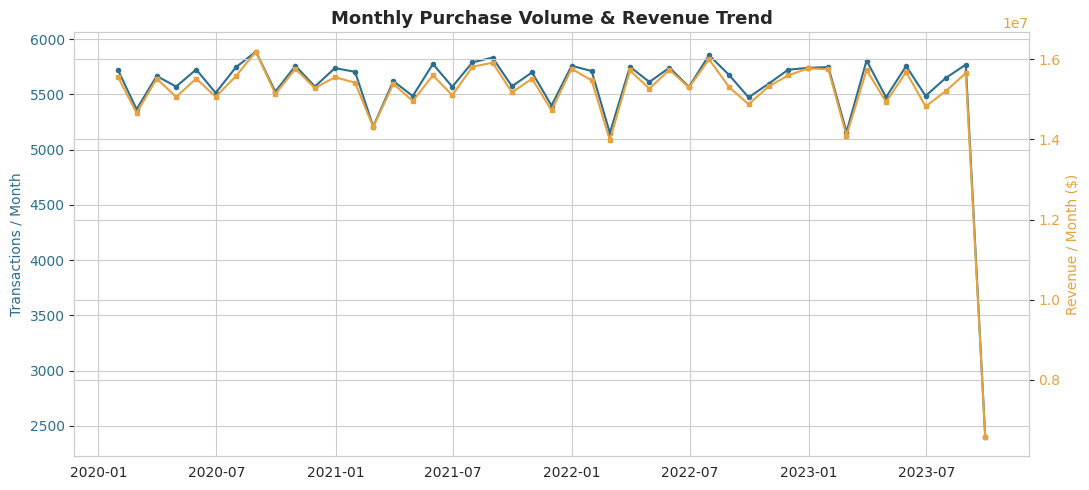

In [19]:
monthly = df.set_index('Purchase Date').resample('ME').agg(
    Transactions=('Customer ID', 'count'),
    Revenue=('Total Purchase Amount', 'sum')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly.index, monthly['Transactions'], color=COLOR_PRIMARY, marker='o', markersize=3, label='Transactions')
ax1.set_ylabel('Transactions / Month', color=COLOR_PRIMARY)
ax1.tick_params(axis='y', labelcolor=COLOR_PRIMARY)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['Revenue'], color=COLOR_ACCENT, marker='s', markersize=3, label='Revenue')
ax2.set_ylabel('Revenue / Month ($)', color=COLOR_ACCENT)
ax2.tick_params(axis='y', labelcolor=COLOR_ACCENT)
ax1.set_title('Monthly Purchase Volume & Revenue Trend', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

Volume and revenue are broadly flat across the observation window, with the normal month-to-month noise expected from a synthetic/randomized transaction log — there's no strong seasonal or growth trend to report.

### 6.4 Product Category Performance

/tmp/ipykernel_629/1416395719.py:8: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(x=cat_summary.index, y=cat_summary['Revenue'], hue=cat_summary.index, palette=PALETTE, legend=False, ax=axes[0])
/tmp/ipykernel_629/1416395719.py:13: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(x=cat_summary.index, y=cat_summary['ReturnRate'] * 100, hue=cat_summary.index, palette=PALETTE, legend=False, ax=axes[1])


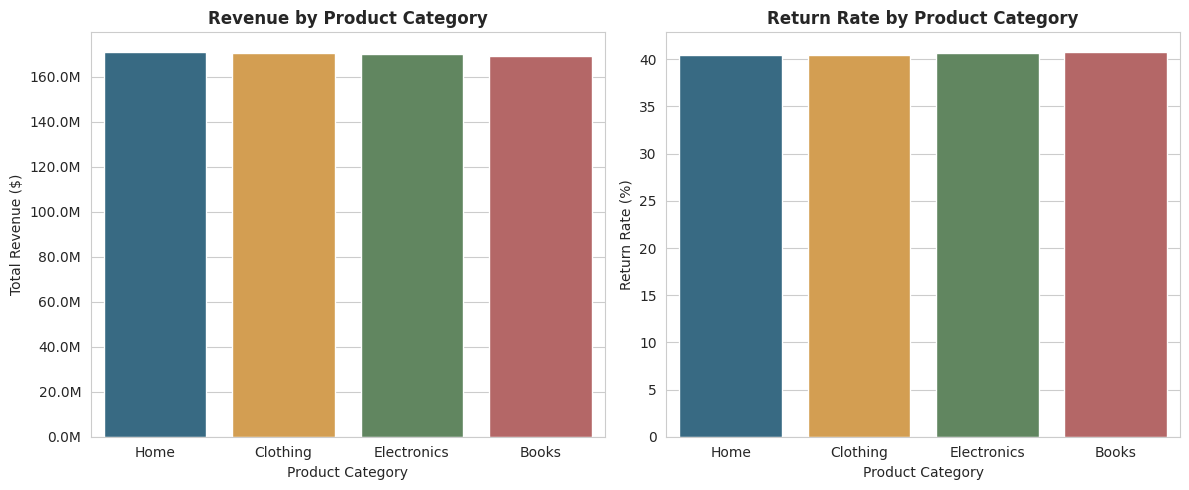

,Revenue,Transactions,ReturnRate
Product Category,,,
Home,171138916,62542,0.404848
Clothing,170716122,62581,0.404308
Electronics,170146025,62630,0.406323
Books,169345236,62247,0.408148


In [20]:
cat_summary = df.groupby('Product Category').agg(
    Revenue=('Total Purchase Amount', 'sum'),
    Transactions=('Customer ID', 'count'),
    ReturnRate=('Returns', 'mean')
).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=cat_summary.index, y=cat_summary['Revenue'], hue=cat_summary.index, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Revenue by Product Category', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

sns.barplot(x=cat_summary.index, y=cat_summary['ReturnRate'] * 100, hue=cat_summary.index, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Return Rate by Product Category', fontweight='bold')
axes[1].set_ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()
cat_summary

### 6.5 Payment Method Mix

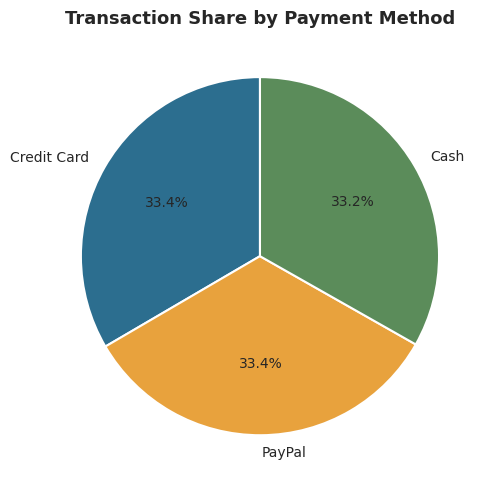

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
pay_counts = df['Payment Method'].value_counts()
ax.pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%', colors=PALETTE,
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Transaction Share by Payment Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Revenue and return rates are nearly identical across all four product categories (Electronics, Clothing, Home, Books), and the three payment methods split the transaction volume almost evenly. This tells us Alfido Tech doesn't have a single underperforming category or payment channel to fix — the opportunity is broader, in overall engagement and retention.

## 7. Retention & Churn Analysis <a id='7'></a>

In [22]:
print("Overall churn rate:", round(customer['Churn'].mean()*100, 1), "%")

Overall churn rate: 20.0 %


### 7.1 Churn Rate by RFM Segment

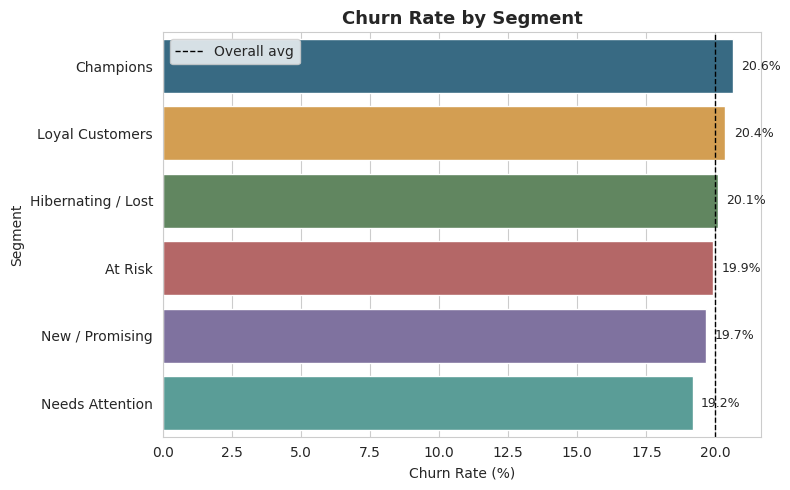

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_seg = customer.groupby('Segment')['Churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=churn_by_seg.values, y=churn_by_seg.index, hue=churn_by_seg.index, palette=PALETTE, legend=False, ax=ax)
ax.set_title('Churn Rate by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.axvline(customer['Churn'].mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall avg')
ax.legend()
for i, v in enumerate(churn_by_seg.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 7.2 Purchase Frequency Distribution & Churn by Recency Bucket

/tmp/ipykernel_629/1352272565.py:10: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(x=churn_by_recency.index, y=churn_by_recency.values, hue=churn_by_recency.index, palette=PALETTE, legend=False, ax=axes[1])


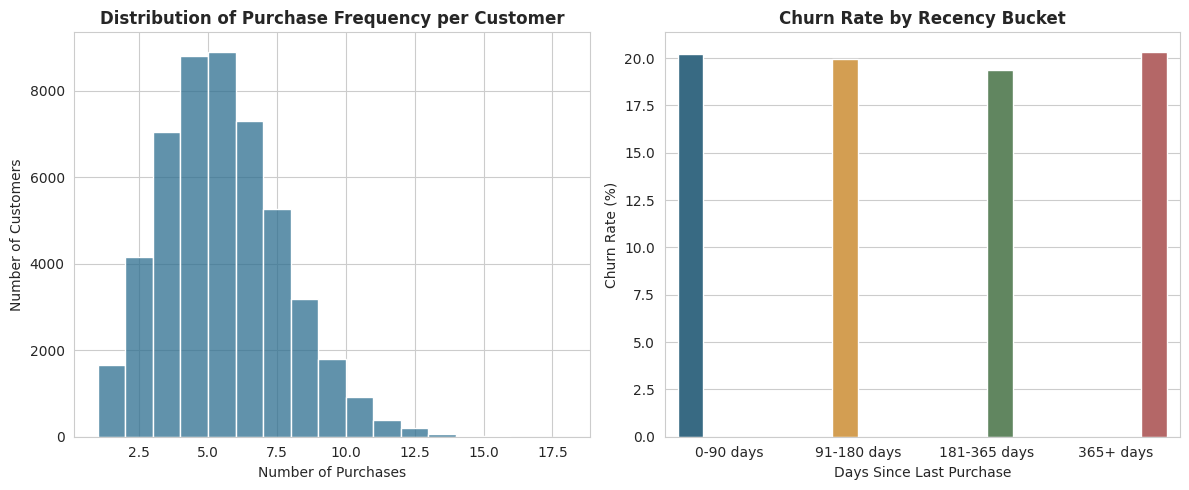

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(customer['Frequency'], bins=range(1, 19), color=COLOR_PRIMARY, ax=axes[0])
axes[0].set_title('Distribution of Purchase Frequency per Customer', fontweight='bold')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Customers')

recency_bins = pd.cut(customer['Recency'], bins=[0, 90, 180, 365, 1000],
                       labels=['0-90 days', '91-180 days', '181-365 days', '365+ days'])
churn_by_recency = customer.groupby(recency_bins, observed=True)['Churn'].mean() * 100
sns.barplot(x=churn_by_recency.index, y=churn_by_recency.values, hue=churn_by_recency.index, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Churn Rate by Recency Bucket', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Days Since Last Purchase')
plt.tight_layout()
plt.show()

**Important finding:** the churn rate is essentially flat (~20%) across every RFM segment and every recency bucket — Champions churn at almost the same rate as Hibernating/Lost customers. Return rate is likewise flat (~40-41%) across all segments. This tells us the `Churn` label in this dataset does **not** correlate with purchase recency, frequency, spend, or returns — it behaves like it was assigned independently of behavior (common in synthetic/simulated datasets like this one).

**Practical implication:** we cannot use this dataset's churn flag to predict *which customers are at risk*. Instead, the RFM segmentation itself — specifically low recency and low frequency — is the most defensible, actionable signal Alfido Tech has for identifying disengaging customers.

### 7.3 Customer Demographics

/tmp/ipykernel_629/869150303.py:7: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(x=gender_churn.index, y=gender_churn.values, hue=gender_churn.index, palette=PALETTE, legend=False, ax=axes[1])


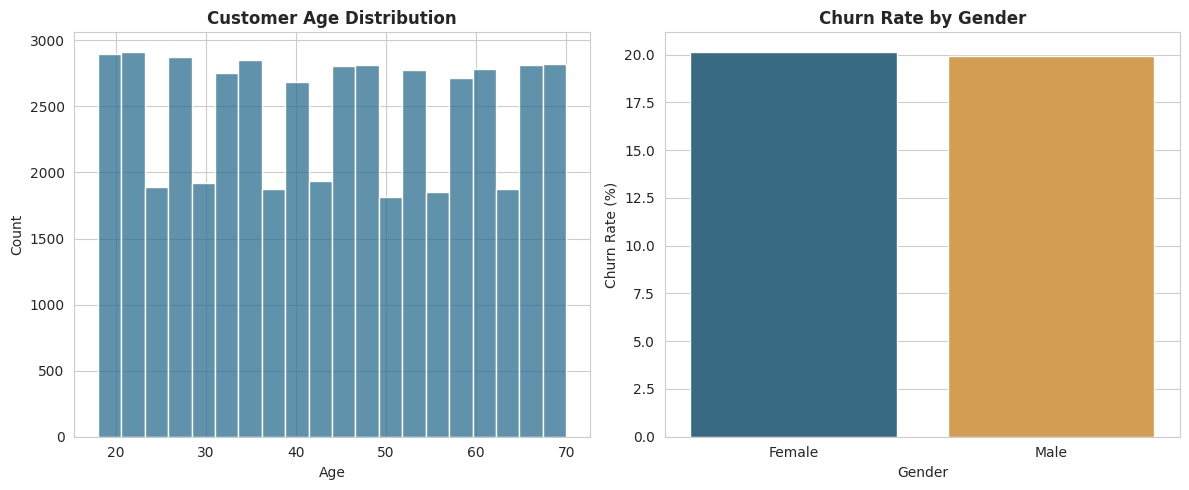

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(customer['Age'], bins=20, color=COLOR_PRIMARY, ax=axes[0])
axes[0].set_title('Customer Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')

gender_churn = df.groupby('Gender')['Churn'].mean() * 100
sns.barplot(x=gender_churn.index, y=gender_churn.values, hue=gender_churn.index, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Churn Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

Age is broadly uniform across the adult range (no concentration in a specific age group), and churn does not vary meaningfully by gender either.

## 8. Key Findings <a id='8'></a>

1. **Six distinct RFM segments** emerge from ~49,700 customers: Champions (7%), Loyal Customers (24%), New/Promising (9%), At Risk (19%), Needs Attention (15%), and Hibernating/Lost (27%, the largest single group).
2. **Hibernating/Lost is the biggest segment by headcount** (~13,200 customers) but contributes the least average lifetime revenue (~$7,400/customer vs. ~$24,100 for Champions) — a large pool of disengaged customers.
3. **At Risk customers carry real value** (~$17,600 average lifetime spend, close to Loyal Customers) but haven't purchased in ~347 days on average — the clearest win-back opportunity.
4. **K-Means clustering broadly confirms the RFM segmentation**, giving confidence the segments reflect genuine behavioral differences, not just scoring artifacts.
5. **Product category and payment method performance is evenly spread** — no single category or payment channel is under- or over-performing, so category-specific fixes are not the priority.
6. **The churn flag is not correlated with purchase behavior** in this dataset (~20% churn rate across every segment and recency bucket) — it cannot be used as a behavioral risk predictor here, so recommendations below focus on the RFM/recency signal instead.
7. **Returns run high across the board** (~40-41%), evenly distributed across segments and categories — this is a broad operational issue, not isolated to one group of customers.


## 9. Actionable Recommendations for Alfido Tech <a id='9'></a>

1. **Launch a win-back campaign for "At Risk" customers.** This ~9,400-customer segment has high historical spend (~$17.6K lifetime) but hasn't purchased in ~11 months. Targeted discounts or "we miss you" offers here have a much higher expected ROI than blanket promotions, because these customers have already proven they'll spend.

2. **Build a loyalty/rewards tier for Champions and Loyal Customers (~31% of the base).** These customers already drive disproportionate revenue — the goal is retention, not acquisition. Early access to new products, tiered perks, or referral incentives can lock in their spend and turn them into advocates.

3. **Create a structured onboarding/nurture flow for "New/Promising" customers.** These ~4,300 recent-but-low-frequency buyers are the best-positioned group to convert into Loyal Customers or Champions. A second-purchase incentive (e.g., a discount that expires 30-45 days after first purchase) directly targets the frequency gap that defines this segment.

4. **Investigate and reduce the ~40% return rate**, which is consistent across every category and segment — pointing to a systemic issue (sizing/fit information, product descriptions, packaging/shipping damage, or a lenient return policy being over-used) rather than a single problematic category. Even a modest reduction here directly improves margin across the entire customer base.

5. **Re-engage the Hibernating/Lost segment selectively, not uniformly.** At 27% of customers this segment is too large to ignore, but its low average spend (~$7,400) means a full win-back campaign likely isn't cost-effective for all of them. Segment further by monetary value: prioritize outreach to the subset with above-median lifetime spend, and consider a low-cost, automated "final offer" email for the rest before suppressing them from regular marketing sends.


---
### Notes on Methodology
- Dataset: 250,000 transaction rows / ~49,700 unique customers, Jan 2020 – Sep 2023, from the Kaggle *Customer Behavior Analysis* dataset.
- Values are synthetic (Product Price × Quantity does not equal Total Purchase Amount), so this analysis focuses on **relative** patterns (segment comparisons, trends, distributions) rather than absolute currency accuracy.
- RFM quartile cut-points were computed on the full customer base; segment boundaries would shift if new data is added and should be periodically refreshed.
